<a href="https://colab.research.google.com/github/Asif1900/Programming-for-Data-Analysis-Project/blob/main/Programming_for_Data_Analysis_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Beijing Air Pollution Analysis and PM2.5 Prediction Project

This notebook presents the full workflow of the Programming for Data Analysis project.  
The aim of this project is to analyse Beijing air pollution data, compare selected urban and suburban stations, discover meaningful pollution patterns, build a PM2.5 prediction model, and prepare the final Streamlit dashboard application.

The project follows a complete data science process:

1. Importing libraries and connecting GitHub  
2. Loading and combining multiple CSV files  
3. Selecting urban and suburban monitoring stations  
4. Understanding and cleaning the dataset  
5. Feature engineering  
6. Exploratory Data Analysis with storytelling insights  
7. Advanced pollution analysis  
8. Machine learning model building and evaluation  
9. Saving files for the Streamlit app  
10. Running the Streamlit dashboard

## 1. Importing Required Libraries

In this section, I import the main Python libraries used throughout the project.  
Pandas and NumPy are used for data handling, Matplotlib and Seaborn are used for static visualizations, and Plotly is used for interactive charts. These libraries help to perform data analysis, visualization, and later dashboard development.

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

## 2. GitHub Repository Setup

This section sets up my GitHub username and repository name.  
GitHub is used to manage the project files, store the dataset, keep track of changes, and show evidence of version control for the assessment.

In [ ]:
username = "Asif1900"
repo = "Programming-for-Data-Analysis-Project"

## 3. Configuring Git User Details

Before cloning or pushing files, I configure my Git username and email.  
This helps GitHub correctly identify who made the changes in the project repository.

In [ ]:
!git config --global user.name "Asif1900"
!git config --global user.email "asifabdullah1900@gmail.com"

## 4. Cloning the GitHub Repository

Here, I clone the project repository from GitHub into Google Colab.  
This allows me to work directly with the files in the repository and keep my analysis connected to my GitHub project structure.

In [ ]:
!git clone https://github.com/{username}/{repo}.git

fatal: destination path 'Programming-for-Data-Analysis-Project' already exists and is not an empty directory.


## 5. Moving into the Project Folder

After cloning the repository, I move into the project folder and list the files.  
This confirms that Colab is working inside the correct project directory.

In [ ]:
%cd {repo}
%ls

/content/Programming-for-Data-Analysis-Project
 all_cities_combined.csv
 app.py
 best_pm25_model.pkl
 cleaned_selected_air_quality.csv
 Programming_for_Data_Analysis_Project.ipynb
 PRSA_Data_Changping_20130301-20170228.csv
'PRSA_Data_Dongsi_20130301-20170228 (1).csv'
 PRSA_Data_Dongsi_20130301-20170228.csv
 PRSA_Data_Guanyuan_20130301-20170228.csv
 PRSA_Data_Huairou_20130301-20170228.csv
 selected_stations_combined.csv


## 6. Loading and Combining Multiple CSV Files

The air pollution dataset is stored in multiple CSV files, where each file represents a monitoring station.  
In this step, I use `glob` to find all CSV files ending with `20170228.csv`, read each file one by one, and combine them into one large dataset.  

Combining the data is important because it allows the analysis to compare multiple stations in one unified dataset.

In [ ]:
import pandas as pd
import glob

city_files = glob.glob("*20170228.csv")

all_cities_data = []

for file_name in city_files:
    city_df = pd.read_csv(file_name)
    all_cities_data.append(city_df)
    print(f"Loaded: {file_name}")

combined_data = pd.concat(all_cities_data, ignore_index=True)

combined_data.to_csv("all_cities_combined.csv", index=False)

print(f"SUCCESS: Combined {len(city_files)} city files into one file with {len(combined_data)} total rows")
print("The combined file is saved as: all_cities_combined.csv")

Loaded: PRSA_Data_Guanyuan_20130301-20170228.csv
Loaded: PRSA_Data_Huairou_20130301-20170228.csv
Loaded: PRSA_Data_Changping_20130301-20170228.csv
Loaded: PRSA_Data_Dongsi_20130301-20170228.csv
SUCCESS: Combined 4 city files into one file with 140256 total rows
The combined file is saved as: all_cities_combined.csv


## 7. Reading the Combined Dataset

After combining all station files, I read the newly created combined CSV file into a DataFrame named `df`.  
This DataFrame becomes the main dataset used for cleaning, analysis, feature engineering, visualization, and model building.

In [ ]:
df = pd.read_csv("all_cities_combined.csv")
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,14.0,20.0,300.0,69.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Guanyuan
1,2,2013,3,1,1,4.0,4.0,13.0,17.0,300.0,72.0,-1.1,1023.2,-18.2,0.0,N,4.7,Guanyuan
2,3,2013,3,1,2,3.0,3.0,10.0,19.0,300.0,69.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Guanyuan
3,4,2013,3,1,3,3.0,6.0,7.0,24.0,400.0,62.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Guanyuan
4,5,2013,3,1,4,3.0,6.0,5.0,14.0,400.0,71.0,-2.0,1025.2,-19.5,0.0,N,2.0,Guanyuan


## 8. Checking Dataset Size

This step checks the number of rows and columns in the dataset.  
It helps to understand the scale of the data before performing deeper analysis.

In [ ]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 140256
Number of columns: 18


## 9. Inspecting Column Names

Here, I display all column names in the dataset.  
This is important because it helps identify pollutant variables, meteorological variables, time variables, and station information.

In [ ]:
df.columns.tolist()

['No',
 'year',
 'month',
 'day',
 'hour',
 'PM2.5',
 'PM10',
 'SO2',
 'NO2',
 'CO',
 'O3',
 'TEMP',
 'PRES',
 'DEWP',
 'RAIN',
 'wd',
 'WSPM',
 'station']

## 10. Checking Data Types

This section checks the data type of each column.  
It helps to confirm whether numeric values, categorical values, and time-related columns are stored correctly before analysis.

In [ ]:
df.dtypes

,0
No,int64
year,int64
month,int64
day,int64
hour,int64
PM2.5,float64
PM10,float64
SO2,float64
NO2,float64
CO,float64


## 11. Statistical Summary of Numeric Variables

The statistical summary provides information such as mean, standard deviation, minimum, maximum, and quartiles.  
This gives an early understanding of pollution levels and weather conditions in the dataset.

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
No,140256.0,17532.500000,10122.141000,1.0000,8766.75,17532.5,26298.250,35064.0
year,140256.0,2014.662560,1.177201,2013.0000,2014.00,2015.0,2016.000,2017.0
month,140256.0,6.522930,3.448715,1.0000,4.00,7.0,10.000,12.0
day,140256.0,15.729637,8.800123,1.0000,8.00,16.0,23.000,31.0
hour,140256.0,11.500000,6.922211,0.0000,5.75,11.5,17.250,23.0
PM2.5,137163.0,77.481501,78.366874,2.0000,20.00,53.0,108.000,882.0
PM10,137915.0,101.399508,89.753213,2.0000,35.00,79.0,141.000,999.0
SO2,137511.0,15.811354,21.822958,0.2856,2.00,7.0,20.000,315.0
NO2,135690.0,47.129503,32.961087,1.0265,22.00,39.0,65.696,270.0
CO,132363.0,1192.068962,1100.290695,100.0000,500.00,900.0,1500.000,10000.0


## 12. Summary of Categorical Variables

This section provides a summary of non-numeric columns such as station names and wind direction.  
It helps to understand categorical values and check whether the station column is correctly available.

In [ ]:
df.describe(include='object')

,wd,station
count,139655,140256
unique,16,4
top,NW,Guanyuan
freq,13107,35064


## 13. Checking Available Stations

Before selecting the required stations, I check how many records exist for each station.  
This confirms that the station column is working properly and helps verify whether all station files were loaded.

In [ ]:
df['station'].value_counts()

,count
station,
Guanyuan,35064
Huairou,35064
Changping,35064
Dongsi,35064


## 14. Selecting Urban and Suburban Stations

For this project, I selected two urban stations and two suburban stations:

- Urban stations: Dongsi and Guanyuan  
- Suburban stations: Changping and Huairou  

This selection allows a meaningful comparison between inner-city pollution and outer-area pollution.

In [ ]:
selected_stations = ['Dongsi', 'Guanyuan', 'Changping', 'Huairou']

df = df[df['station'].isin(selected_stations)].copy()

print(df['station'].value_counts())
print(df.shape)

station
Guanyuan     35064
Huairou      35064
Changping    35064
Dongsi       35064
Name: count, dtype: int64
(140256, 18)


## 15. Saving the Selected Station Dataset

After filtering the dataset to only the four selected stations, I save it as a separate CSV file.  
This creates a clean intermediate dataset that can be reused later without repeating the filtering process.

In [ ]:
df.to_csv("selected_stations_combined.csv", index=False)
print("Filtered dataset saved as selected_stations_combined.csv")

Filtered dataset saved as selected_stations_combined.csv


## 16. Missing Value Analysis Function

Real-world datasets often contain missing values.  
This function calculates the number and percentage of missing values for each column. It helps identify which variables need cleaning before analysis and modelling.

In [ ]:
def missing_values_table(dataframe):
    missing_count = dataframe.isnull().sum()
    missing_percent = (missing_count / len(dataframe)) * 100

    table = pd.DataFrame({
        'Missing Values': missing_count,
        'Percentage (%)': missing_percent
    })

    table = table.sort_values(by='Percentage (%)', ascending=False)
    return table

## 17. Displaying Missing Values

Here, I apply the missing value function to the selected station dataset.  
This gives a clear view of data quality issues before cleaning.

In [ ]:
missing_table = missing_values_table(df)
missing_table

,Missing Values,Percentage (%)
CO,7893,5.627567
NO2,4566,3.255476
O3,3592,2.561031
PM2.5,3093,2.205253
SO2,2745,1.957136
PM10,2341,1.669091
wd,601,0.428502
RAIN,146,0.104095
DEWP,146,0.104095
TEMP,144,0.102669


## 18. Visual Display of Missing Values

This styled table makes the missing value pattern easier to read.  
Columns with higher missing percentages become visually clearer, which supports better data cleaning decisions.

In [ ]:
missing_table.style.background_gradient(cmap='Blues')

,Missing Values,Percentage (%)
CO,7893,5.627567
NO2,4566,3.255476
O3,3592,2.561031
PM2.5,3093,2.205253
SO2,2745,1.957136
PM10,2341,1.669091
wd,601,0.428502
RAIN,146,0.104095
DEWP,146,0.104095
TEMP,144,0.102669


## 19. Checking Duplicate Rows

Duplicate rows can affect analysis and model accuracy.  
In this step, I check whether duplicate records exist in the dataset.

In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## 20. Removing Duplicate Rows

If duplicates exist, they are removed to make the dataset cleaner and more reliable.  
This improves the quality of both EDA and machine learning.

In [ ]:
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (140256, 18)


## 21. Creating a Proper Datetime Column

The original dataset stores year, month, day, and hour separately.  
I combine these columns into one `datetime` column so that time-based analysis can be performed properly.

In [ ]:
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df[['year', 'month', 'day', 'hour', 'datetime']].head()

,year,month,day,hour,datetime
0,2013,3,1,0,2013-03-01 00:00:00
1,2013,3,1,1,2013-03-01 01:00:00
2,2013,3,1,2,2013-03-01 02:00:00
3,2013,3,1,3,2013-03-01 03:00:00
4,2013,3,1,4,2013-03-01 04:00:00


## 22. Sorting Data by Station and Time

Sorting the dataset by station and datetime helps maintain the correct chronological order.  
This is especially important for time-series analysis and lag feature creation.

In [ ]:
df = df.sort_values(by=['station', 'datetime']).reset_index(drop=True)

## 23. Handling Missing Numeric Values

Missing numeric values are filled using the median value within each station.  
This is better than using one global value because pollution levels can differ between stations.

In [ ]:
numeric_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

for col in numeric_cols:
    if col in df.columns:
        df[col] = df.groupby('station')[col].transform(lambda x: x.fillna(x.median()))

## 24. Handling Missing Wind Direction Values

Wind direction is a categorical variable.  
If missing values exist in this column, I fill them using the most frequent wind direction.

In [ ]:
if 'wd' in df.columns:
    df['wd'] = df['wd'].fillna(df['wd'].mode()[0])

## 25. Confirming Missing Values After Cleaning

After handling missing values, I check the missing value table again.  
This confirms whether the dataset is now ready for feature engineering and analysis.

In [ ]:
missing_values_table(df)

,Missing Values,Percentage (%)
No,0,0.0
year,0,0.0
month,0,0.0
day,0,0.0
hour,0,0.0
PM2.5,0,0.0
PM10,0,0.0
SO2,0,0.0
NO2,0,0.0
CO,0,0.0


## 26. Creating Time-Based Features

Time-based features are created from the datetime column.  
These features help explore daily, weekly, monthly, and seasonal pollution patterns.

In [ ]:
df['day_of_week'] = df['datetime'].dt.day_name()
df['month_name'] = df['datetime'].dt.month_name()
df['weekend'] = df['datetime'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)

## 27. Creating a Season Feature

Season is an important feature because air pollution often changes with weather conditions.  
This function converts each month into Spring, Summer, Autumn, or Winter.

In [ ]:
def get_season(month):
    if month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Autumn'
    else:
        return 'Winter'

df['season'] = df['month'].apply(get_season)

## 28. Creating Urban and Suburban Area Type

This feature separates the selected stations into urban and suburban groups.  
It supports one of the main stories of the project: comparing pollution levels between inner-city and outer-area monitoring stations.

In [ ]:
df['area_type'] = df['station'].map({
    'Dongsi': 'Urban',
    'Guanyuan': 'Urban',
    'Changping': 'Suburban',
    'Huairou': 'Suburban'
})

## 29. Creating PM2.5 Pollution Level Categories

PM2.5 values are converted into pollution categories such as Good, Moderate, Unhealthy, and Hazardous.  
This makes the results easier to understand for non-technical users and is useful for the final dashboard.

"""
    Categorises PM2.5 concentration using China's AQI PM2.5 24-hour breakpoints.

    Source:
    Technical Regulation on Ambient Air Quality Index (on trial), HJ 633-2012,
    issued under China's national air quality framework. PM2.5 breakpoints:
    0–35: Excellent
    35–75: Good
    75–115: Lightly Polluted
    115–150: Moderately Polluted
    150–250: Heavily Polluted
    250–500+: Severely Polluted

    Reference:
    Ministry of Ecology and Environment of the People's Republic of China,
    Ambient Air Quality Standards (GB 3095-2012).
    https://english.mee.gov.cn/Resources/standards/Air_Environment/quality_standard1/201605/t20160511_337502.shtml

    HJ 633-2012: Technical Regulation on Ambient Air Quality Index.
    """


In [ ]:
def pm25_category_china(value):

    if pd.isna(value):
        return np.nan
    elif value <= 35:
        return "Excellent"
    elif value <= 75:
        return "Good"
    elif value <= 115:
        return "Lightly Polluted"
    elif value <= 150:
        return "Moderately Polluted"
    elif value <= 250:
        return "Heavily Polluted"
    else:
        return "Severely Polluted"


df["PM2.5_Level"] = df["PM2.5"].apply(pm25_category_china)

## 30. Saving the Cleaned Dataset

After cleaning and feature engineering, I save the final cleaned dataset.  
This dataset will be used for EDA, model building, and the Streamlit dashboard.

In [ ]:
df.to_csv("cleaned_selected_air_quality.csv", index=False)
print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


## 31. Final Dataset Information

This section displays the final structure of the cleaned dataset.  
It confirms that all new features have been added and the dataset is ready for deeper analysis.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140256 entries, 0 to 140255
Data columns (total 25 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   No           140256 non-null  int64         
 1   year         140256 non-null  int64         
 2   month        140256 non-null  int64         
 3   day          140256 non-null  int64         
 4   hour         140256 non-null  int64         
 5   PM2.5        140256 non-null  float64       
 6   PM10         140256 non-null  float64       
 7   SO2          140256 non-null  float64       
 8   NO2          140256 non-null  float64       
 9   CO           140256 non-null  float64       
 10  O3           140256 non-null  float64       
 11  TEMP         140256 non-null  float64       
 12  PRES         140256 non-null  float64       
 13  DEWP         140256 non-null  float64       
 14  RAIN         140256 non-null  float64       
 15  wd           140256 non-null  obje

# Exploratory Data Analysis: Visualizations

The next section focuses on visual analysis.  
The aim is not only to create graphs, but to give a clear insights about pollution behaviour across stations, time, weather conditions, and environmental factors.

## 32. Setting Up Visualization Style

Before creating plots, I set a clean whitegrid style for Seaborn and adjust the default figure size.  
This makes the visualizations easier to read and more professional.

In [ ]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]], errors="coerce")

selected_stations = ["Dongsi", "Guanyuan", "Changping", "Huairou"]
df = df[df["station"].isin(selected_stations)].copy()

df["area_type"] = df["station"].map({
    "Dongsi": "Urban",
    "Guanyuan": "Urban",
    "Changping": "Suburban",
    "Huairou": "Suburban"
})

def get_season(month):
    if month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    elif month in [9, 10, 11]:
        return "Autumn"
    return "Winter"

df["season"] = df["month"].apply(get_season)
df["day_of_week"] = df["datetime"].dt.day_name()
df["weekend"] = df["datetime"].dt.dayofweek.apply(lambda x: "Weekend" if x >= 5 else "Weekday")

## 33. Average PM2.5 Concentration by Station

This visualization shows which selected station has the highest average PM2.5 concentration.  
It directly supports the station-based pollution story and helps compare urban and suburban air quality.

/tmp/ipykernel_36866/2676277849.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


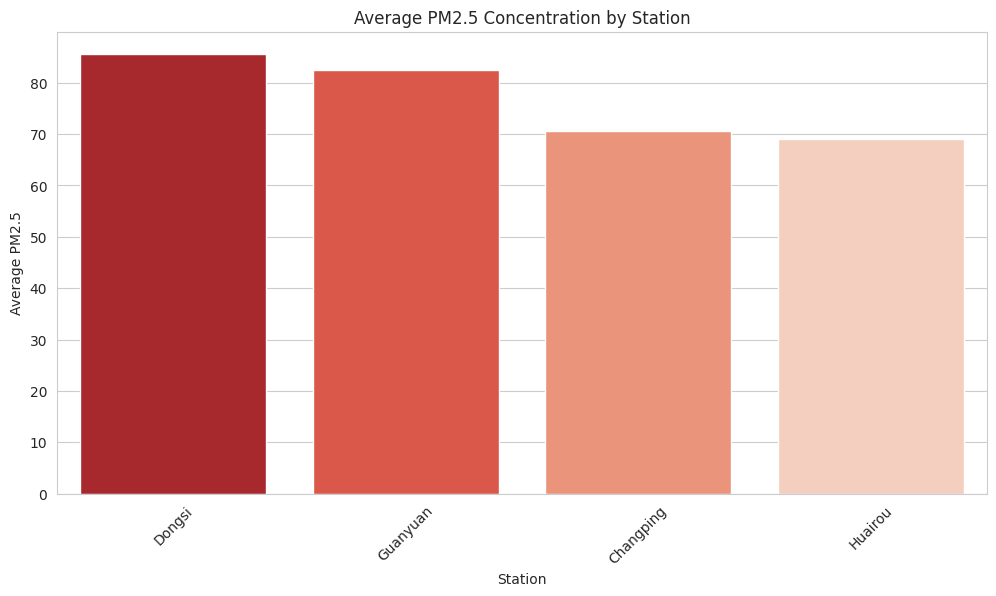

In [ ]:
station_pollution = df.groupby('station')['PM2.5'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(
    x=station_pollution.index,
    y=station_pollution.values,
    palette='Reds_r'
)

plt.title('Average PM2.5 Concentration by Station')
plt.xlabel('Station')
plt.ylabel('Average PM2.5')
plt.xticks(rotation=45)
plt.show()

## 34. Temperature and PM2.5 Relationship

This plot investigates whether temperature is related to PM2.5 concentration.  
It helps explain how weather conditions may influence pollution levels.

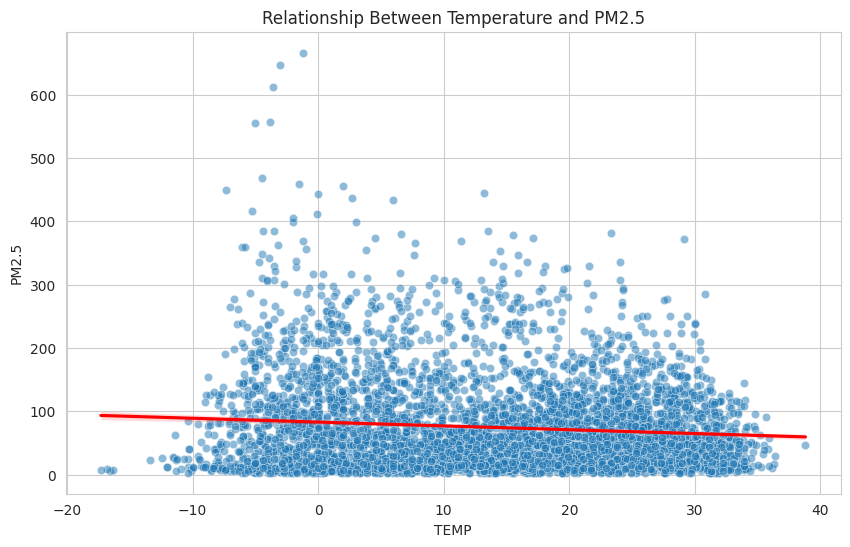

In [ ]:
sample_temp = df.sample(min(5000, len(df)), random_state=42)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=sample_temp,
    x='TEMP',
    y='PM2.5',
    alpha=0.5
)

sns.regplot(
    data=sample_temp,
    x='TEMP',
    y='PM2.5',
    scatter=False,
    color='red'
)

plt.title('Relationship Between Temperature and PM2.5')
plt.show()

## 35. Wind Speed and PM2.5 Relationship

This visualization explores whether wind speed helps reduce PM2.5 concentration.  
It is important because wind can disperse pollutants and improve air quality.

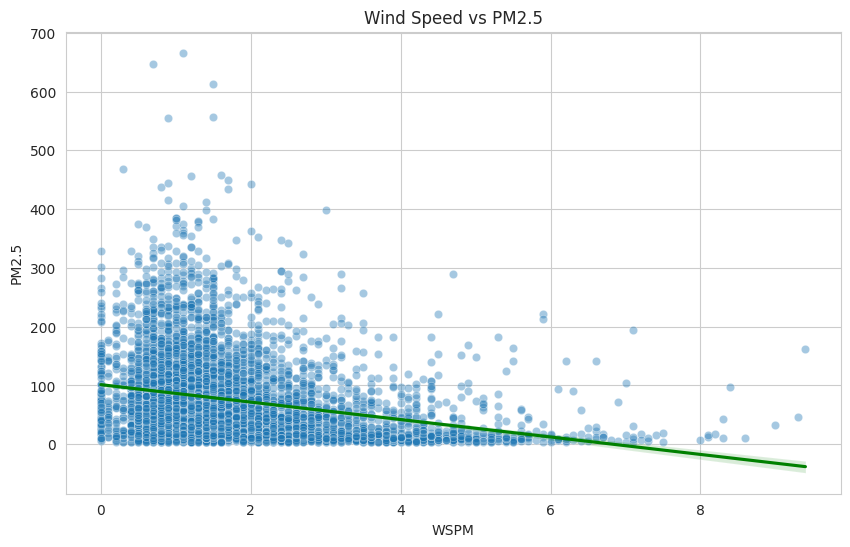

In [ ]:
sample_wind = df.sample(min(5000, len(df)), random_state=42)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=sample_wind,
    x='WSPM',
    y='PM2.5',
    alpha=0.4
)

sns.regplot(
    data=sample_wind,
    x='WSPM',
    y='PM2.5',
    scatter=False,
    color='green'
)

plt.title('Wind Speed vs PM2.5')
plt.show()

## 36. Correlation Between Pollutants

This heatmap shows how different pollutants move together.  
It helps identify whether particulate matter and gas pollutants may share similar sources such as traffic or industrial activity.

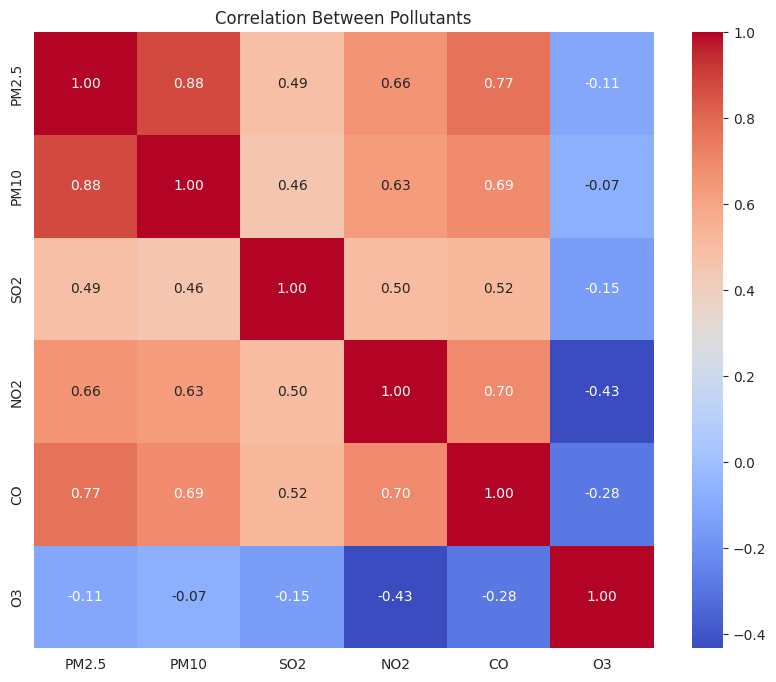

In [ ]:
pollutants = ['PM2.5','PM10','SO2','NO2','CO','O3']

corr = df[pollutants].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Between Pollutants')
plt.show()

## 37. Average PM2.5 by Hour of Day

This plot shows how PM2.5 changes during different hours of the day.  
It helps identify daily activity patterns such as morning and evening pollution changes.

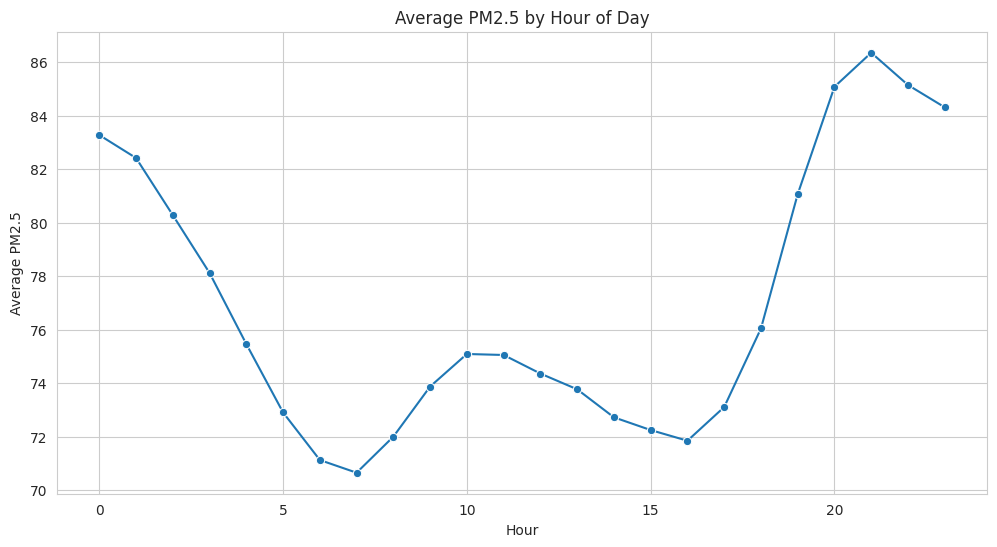

In [ ]:
hourly_pm25 = df.groupby('hour')['PM2.5'].mean()

plt.figure(figsize=(12,6))

sns.lineplot(
    x=hourly_pm25.index,
    y=hourly_pm25.values,
    marker='o'
)

plt.title('Average PM2.5 by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Average PM2.5')
plt.show()

## 38. Average PM2.5 by Season

Seasonal analysis is important because air pollution is strongly affected by weather.  
This visualization identifies which season has the highest average PM2.5 concentration.

/tmp/ipykernel_36866/20092270.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


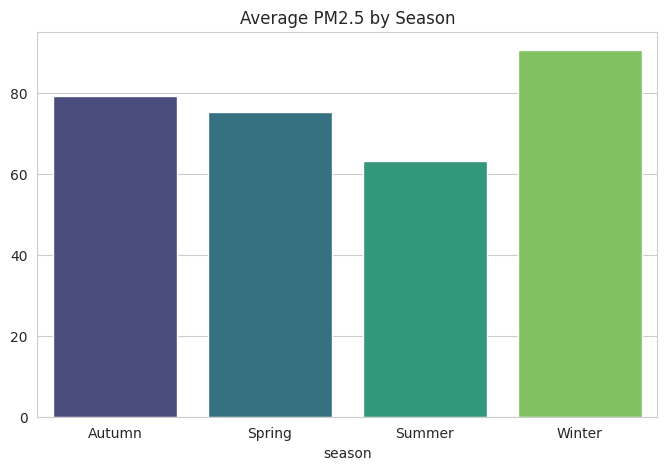

In [ ]:
season_pm25 = df.groupby('season')['PM2.5'].mean()

plt.figure(figsize=(8,5))

sns.barplot(
    x=season_pm25.index,
    y=season_pm25.values,
    palette='viridis'
)

plt.title('Average PM2.5 by Season')
plt.show()

## 39. Urban vs Suburban PM2.5

This plot compares pollution levels between urban and suburban stations.  
It connects directly with the project station selection and helps show whether city-centre areas experience higher pollution.

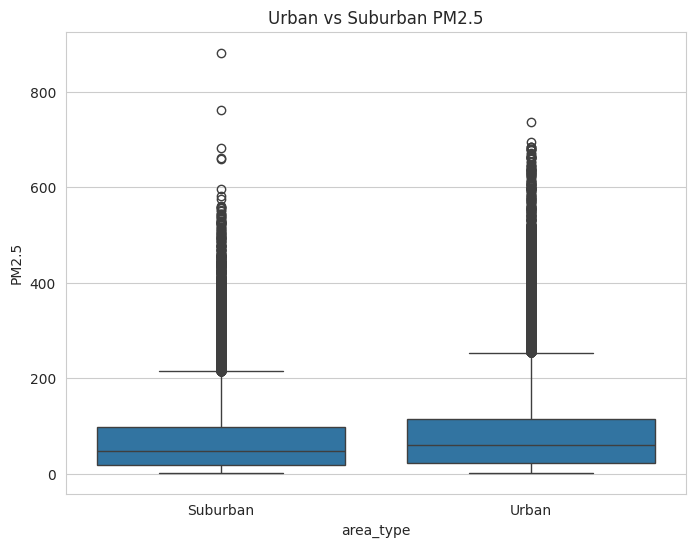

In [ ]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='area_type',
    y='PM2.5'
)

plt.title('Urban vs Suburban PM2.5')
plt.show()

## 40. Monthly PM2.5 Trend Over Time

This time-series plot shows long-term PM2.5 movement across the study period.  
It helps reveal seasonal spikes, repeated pollution cycles, and possible changes over time.

/tmp/ipykernel_36866/1643248829.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_trend = df.groupby(pd.Grouper(key='datetime', freq='M'))['PM2.5'].mean()


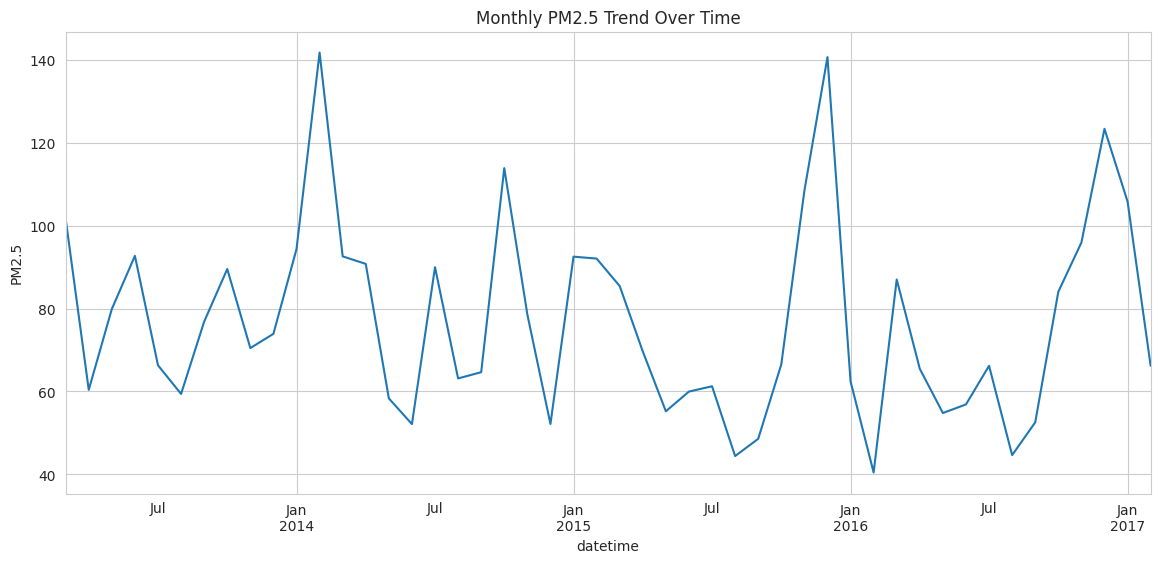

In [ ]:
monthly_trend = df.groupby(pd.Grouper(key='datetime', freq='M'))['PM2.5'].mean()

plt.figure(figsize=(14,6))

monthly_trend.plot()

plt.title('Monthly PM2.5 Trend Over Time')
plt.ylabel('PM2.5')
plt.show()

## 41. Effect of Rain on PM2.5

Rain can naturally remove particles from the air.  
This visualization explores whether rainfall is associated with lower PM2.5 concentration.

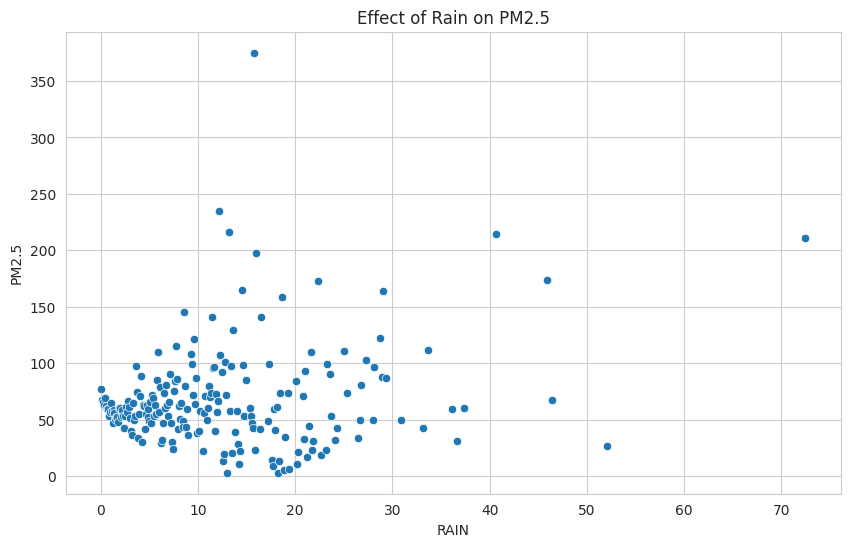

In [ ]:
rain_effect = df.groupby('RAIN')['PM2.5'].mean().reset_index()

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rain_effect,
    x='RAIN',
    y='PM2.5'
)

plt.title('Effect of Rain on PM2.5')
plt.show()

## 42. Pollution Hotspots by Station and Month

This heatmap combines station and month together to identify pollution hotspots.  
It is useful for finding which stations and months repeatedly experience high PM2.5 levels.

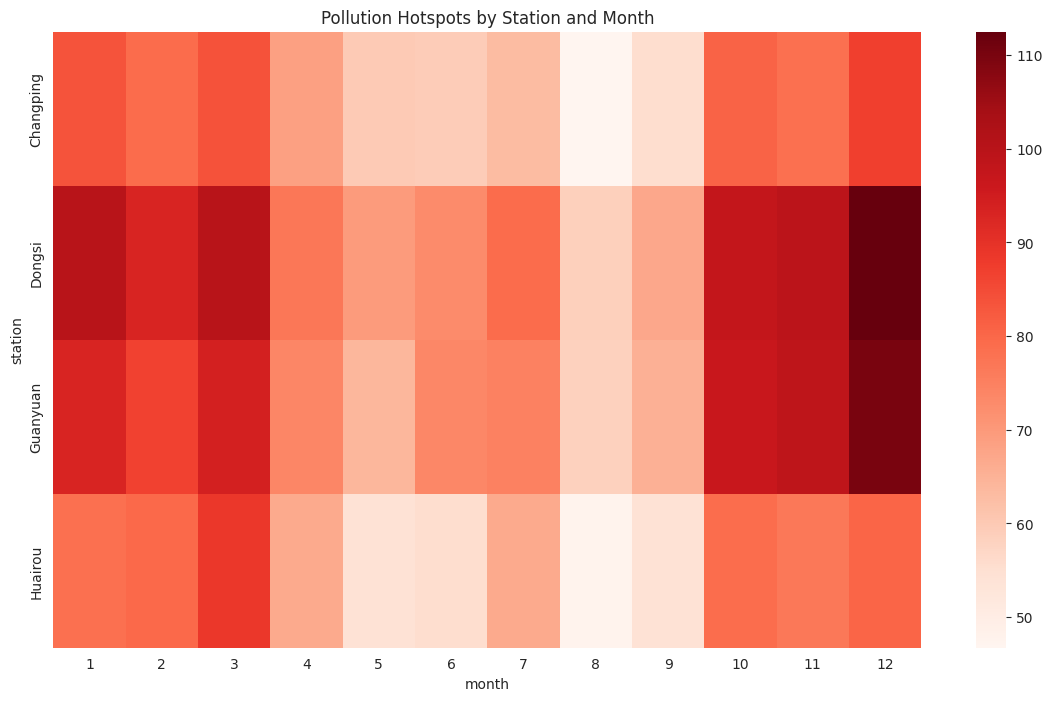

In [ ]:
pivot_table = df.pivot_table(
    values='PM2.5',
    index='station',
    columns='month',
    aggfunc='mean'
)

plt.figure(figsize=(14,8))

sns.heatmap(
    pivot_table,
    cmap='Reds'
)

plt.title('Pollution Hotspots by Station and Month')
plt.show()

# Advanced EDA : Advanced Visualizations

The next visualizations are designed to move the analysis beyond basic plots.  
They investigate extreme pollution events, wind conditions, traffic-related patterns, station similarity, and combined temperature-wind risk. These plots help the notebook tell a stronger environmental insights.

## 43. Extreme Pollution Episode Timeline

This interactive plot identifies days when PM2.5 reached unhealthy levels.  
Instead of only looking at average pollution, this plot highlights dangerous pollution episodes over time.

In [ ]:
df["date"] = df["datetime"].dt.date
df["high_pollution"] = df["PM2.5"] > 150

daily_episode = df.groupby("date").agg(
    avg_pm25=("PM2.5", "mean"),
    high_events=("high_pollution", "sum")
).reset_index()

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=daily_episode["date"],
    y=daily_episode["avg_pm25"],
    mode="lines",
    name="Daily Average PM2.5",
    line=dict(width=2)
))

fig.add_trace(go.Scatter(
    x=daily_episode[daily_episode["avg_pm25"] > 150]["date"],
    y=daily_episode[daily_episode["avg_pm25"] > 150]["avg_pm25"],
    mode="markers",
    name="Extreme Pollution Days",
    marker=dict(size=8, color="red")
))

fig.add_hline(
    y=150,
    line_dash="dash",
    line_color="red",
    annotation_text="Unhealthy Threshold"
)

fig.update_layout(
    title="Extreme Pollution Episodes Over Time",
    xaxis_title="Date",
    yaxis_title="PM2.5",
    template="plotly_white",
    height=500
)

fig.show()

## 44. Impact of Wind Conditions on PM2.5 by Station

This plot compares PM2.5 levels under low wind and higher wind conditions for each station.  
It helps explain whether stagnant air increases pollution accumulation.

In [ ]:
df["wind_condition"] = np.where(df["WSPM"] < 2, "Low Wind", "Higher Wind")

wind_station = df.groupby(["station", "wind_condition"])["PM2.5"].mean().reset_index()

fig = px.bar(
    wind_station,
    x="station",
    y="PM2.5",
    color="wind_condition",
    barmode="group",
    title="Impact of Wind Conditions on PM2.5 by Station",
    labels={"PM2.5": "Average PM2.5", "station": "Station", "wind_condition": "Wind Condition"}
)

fig.update_layout(
    template="plotly_white",
    height=500,
    legend_title="Wind Condition"
)

fig.show()

## 45. NO2 Traffic Pollution Signature Across the Day

NO2 is strongly linked with vehicle emissions.  
This plot highlights morning and evening rush-hour periods to investigate whether traffic activity affects pollution.

In [ ]:
df["rush_period"] = df["hour"].apply(
    lambda x: "Morning Rush" if x in [7, 8, 9]
    else "Evening Rush" if x in [17, 18, 19]
    else "Other Hours"
)

rush_summary = df.groupby(["hour", "station"])["NO2"].mean().reset_index()

fig = px.line(
    rush_summary,
    x="hour",
    y="NO2",
    color="station",
    markers=True,
    title="NO2 Traffic Pollution Signature Across the Day",
    labels={"NO2": "Average NO2", "hour": "Hour of Day"}
)

fig.add_vrect(x0=7, x1=9, fillcolor="orange", opacity=0.18, line_width=0)
fig.add_vrect(x0=17, x1=19, fillcolor="red", opacity=0.15, line_width=0)

fig.add_annotation(x=8, y=rush_summary["NO2"].max(), text="Morning Rush", showarrow=False)
fig.add_annotation(x=18, y=rush_summary["NO2"].max(), text="Evening Rush", showarrow=False)

fig.update_layout(
    template="plotly_white",
    height=500
)

fig.show()

## 46. Station Similarity Based on Monthly PM2.5 Behaviour

This heatmap investigates whether selected stations behave similarly over time.  
High similarity suggests that stations may be influenced by shared weather patterns or regional pollution sources.

In [ ]:
station_monthly = df.pivot_table(
    values="PM2.5",
    index=df["datetime"].dt.to_period("M").astype(str),
    columns="station",
    aggfunc="mean"
)

station_corr = station_monthly.corr()

fig = go.Figure(data=go.Heatmap(
    z=station_corr.values,
    x=station_corr.columns,
    y=station_corr.index,
    colorscale="Blues",
    text=np.round(station_corr.values, 2),
    texttemplate="%{text}",
    zmin=0,
    zmax=1
))

fig.update_layout(
    title="Station Similarity Based on Monthly PM2.5 Behaviour",
    xaxis_title="Station",
    yaxis_title="Station",
    template="plotly_white",
    height=550
)

fig.show()

## 47. PM2.5 Risk Under Combined Temperature and Wind Conditions

This plot combines temperature and wind speed to investigate high-risk environmental conditions.  
It helps explain why pollution can become severe during cold and low-wind periods.

In [ ]:
df["condition_type"] = np.select(
    [
        (df["TEMP"] < 0) & (df["WSPM"] < 2),
        (df["TEMP"] < 0) & (df["WSPM"] >= 2),
        (df["TEMP"] >= 0) & (df["WSPM"] < 2),
        (df["TEMP"] >= 0) & (df["WSPM"] >= 2)
    ],
    [
        "Cold + Low Wind",
        "Cold + Higher Wind",
        "Warm + Low Wind",
        "Warm + Higher Wind"
    ],
    default="Other"
)

condition_station = df.groupby(["condition_type", "station"])["PM2.5"].mean().reset_index()

order = [
    "Cold + Low Wind",
    "Cold + Higher Wind",
    "Warm + Low Wind",
    "Warm + Higher Wind"
]

fig = px.bar(
    condition_station,
    x="condition_type",
    y="PM2.5",
    color="station",
    barmode="group",
    category_orders={"condition_type": order},
    title="PM2.5 Risk Under Combined Temperature and Wind Conditions",
    labels={"condition_type": "Environmental Condition", "PM2.5": "Average PM2.5"}
)

fig.update_layout(
    template="plotly_white",
    height=550,
    xaxis_tickangle=-20
)

fig.show()

## 48. 3D Relationship Between Temperature, Wind Speed, and PM2.5

This interactive 3D visualization explores three variables together.  
It helps show how temperature, wind speed, and PM2.5 interact across different stations.

In [ ]:
sample_df = df[["TEMP", "WSPM", "PM2.5", "station"]].dropna().sample(
    min(5000, df[["TEMP", "WSPM", "PM2.5", "station"]].dropna().shape[0]),
    random_state=42
)

fig = px.scatter_3d(
    sample_df,
    x="TEMP",
    y="WSPM",
    z="PM2.5",
    color="station",
    title="3D Relationship Between Temperature, Wind Speed, and PM2.5"
)
fig.show()

## 49. Bubble Plot: PM2.5, Temperature, and CO

This bubble plot adds another dimension by using CO as the bubble size.  
It helps explore whether higher CO levels appear together with higher PM2.5 values.

In [ ]:
sample_df = df[["TEMP", "PM2.5", "CO", "station"]].dropna().sample(
    min(5000, df[["TEMP", "PM2.5", "CO", "station"]].dropna().shape[0]),
    random_state=42
)

fig = px.scatter(
    sample_df,
    x="TEMP",
    y="PM2.5",
    size="CO",
    color="station",
    title="PM2.5 vs Temperature (Bubble Size = CO)"
)
fig.show()

# Machine Learning Model Building

After completing the EDA, I build a machine learning model to predict PM2.5 concentration.  
PM2.5 was selected as the target variable because it is one of the most important air pollution indicators for public health.

## 50. Preparing the Modelling Dataset

A lag feature is created using the previous hour's PM2.5 value.  
This is useful because air pollution has time dependency, meaning the current PM2.5 level can be influenced by the previous hour's level.

In [ ]:
model_df = df.copy()

model_df['PM2.5_lag1'] = model_df.groupby('station')['PM2.5'].shift(1)

model_df = model_df.dropna()

## 51. Selecting Features and Target Variable

Here, I select pollutant variables, weather variables, and the lag feature as input features.  
The target variable is PM2.5, which the model will learn to predict.

In [ ]:
features = [
    'PM10', 'SO2', 'NO2', 'CO', 'O3',
    'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM',
    'PM2.5_lag1'
]

target = 'PM2.5'

X = model_df[features]
y = model_df[target]

## 52. Splitting Data into Training and Testing Sets

The dataset is divided into training and testing sets.  
The training set is used to train the model, and the testing set is used to evaluate how well the model performs on unseen data.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 53. Creating a Machine Learning Pipeline

A pipeline is used to combine feature scaling and Random Forest regression in one structured workflow.  
This makes the modelling process cleaner, more professional, and easier to reproduce.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(random_state=42))
])

## 54. Hyperparameter Tuning with GridSearchCV

GridSearchCV is used to test different Random Forest parameter combinations.  
This improves the model because it searches for the best settings instead of using default parameters only.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(random_state=42))
])

param_grid = {
    'model__n_estimators': [80],
    'model__max_depth': [20],
    'model__min_samples_split': [2]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=2,
    scoring='r2',
    n_jobs=1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'model__max_depth': 20, 'model__min_samples_split': 2, 'model__n_estimators': 80}


## 55. Cross-Validation

Cross-validation checks how well the model performs across different parts of the dataset.  
This helps confirm that the model is not only performing well on one train-test split.

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='r2')

print("CV Scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())

CV Scores: [0.94629612 0.96007135 0.96907926 0.96426441 0.96194772]
Mean CV R2: 0.9603317704352714


## 56. Final Model Evaluation

The final tuned model is evaluated using RMSE and R2 score.  
RMSE shows the average prediction error, while R2 shows how much variation in PM2.5 is explained by the model.

In [56]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Final Model Performance:")
print("RMSE:", rmse)
print("R2:", r2)

Final Model Performance:
RMSE: 14.886635042968274
R2: 0.9624446099762963


## 57. Residual Distribution

Residuals are the differences between actual and predicted values.  
This plot helps check whether the model errors are balanced or biased.

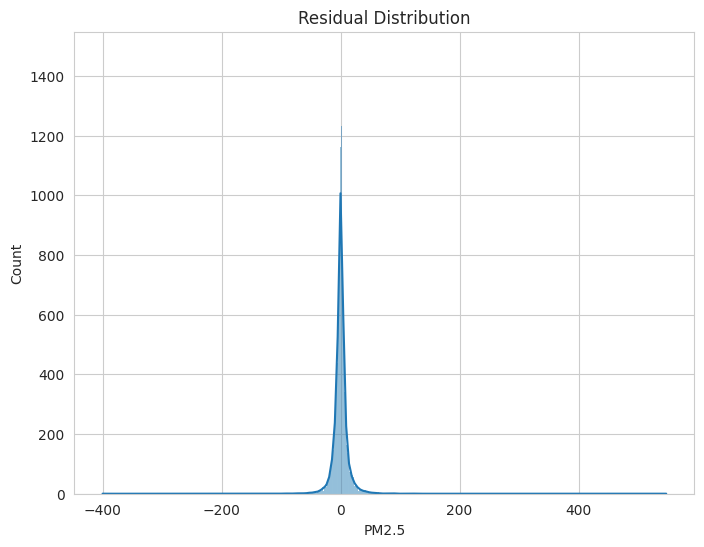

In [57]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

## 58. Residuals vs Predictions

This plot checks whether prediction errors follow a clear pattern.  
If the residuals are randomly spread around zero, the model is behaving more reliably.

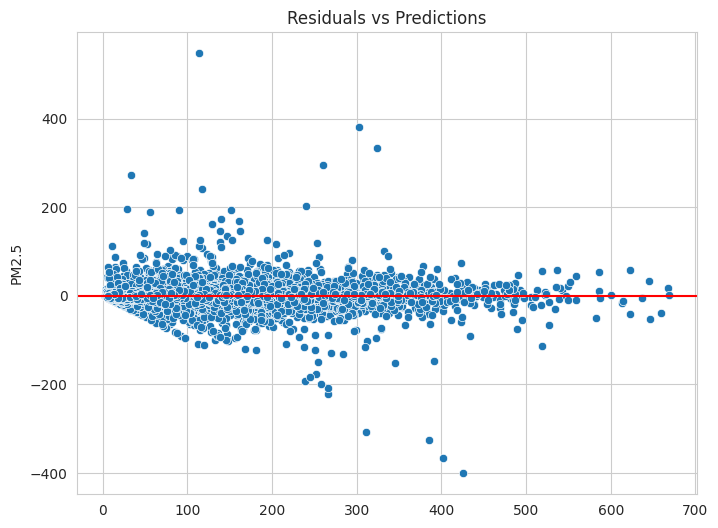

In [58]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red')
plt.title("Residuals vs Predictions")
plt.show()

## 59. Feature Importance

Feature importance shows which variables had the strongest influence on PM2.5 prediction.  
This connects the machine learning result back to the EDA and helps interpret the model.

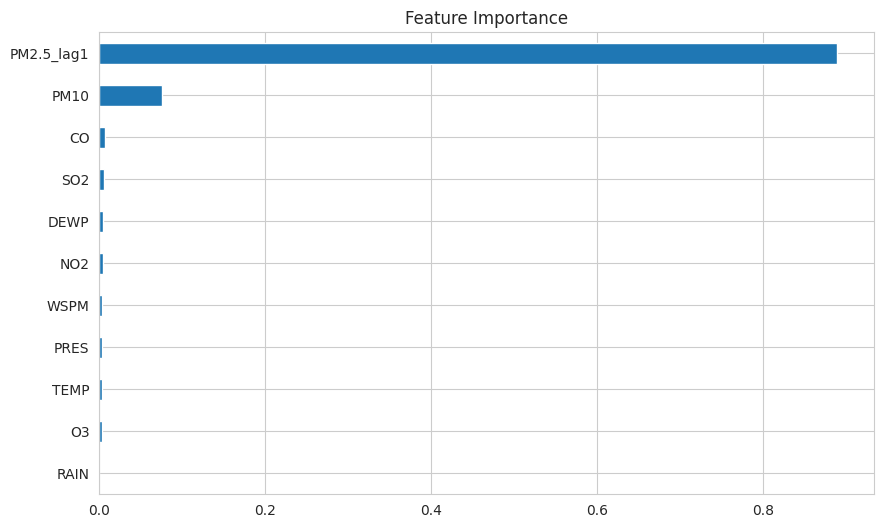

In [59]:
model = best_model.named_steps['model']

importance = pd.Series(model.feature_importances_, index=features)

importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

## 60. Actual vs Predicted PM2.5

This plot compares the model's predicted PM2.5 values with the real values.  
A closer alignment between actual and predicted values indicates better model performance.

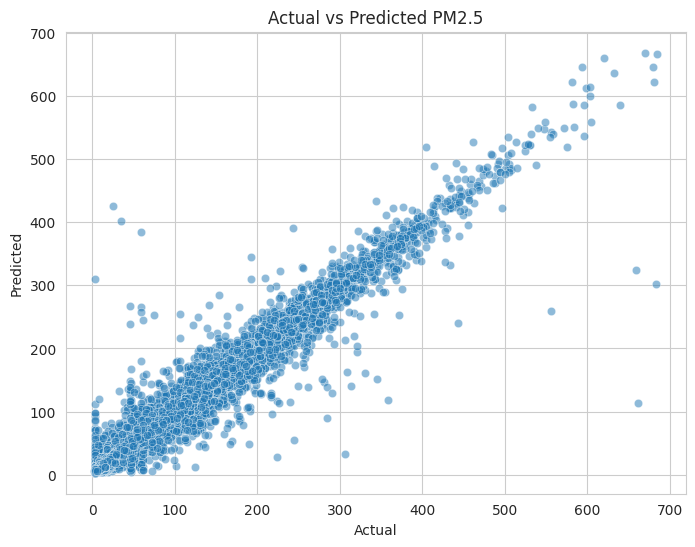

In [60]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted PM2.5")
plt.show()

## 61. Saving the Trained Model

The final trained model is saved as a `.pkl` file using joblib.  
This saved model is later loaded inside the Streamlit app for PM2.5 prediction.

In [61]:
import joblib

joblib.dump(best_model, "best_pm25_model.pkl")

['best_pm25_model.pkl']

## 62. SHAP Explainability Analysis

SHAP is used as an advanced explainability technique.  
It helps show how each feature contributes to PM2.5 predictions, making the model more transparent and easier to interpret.

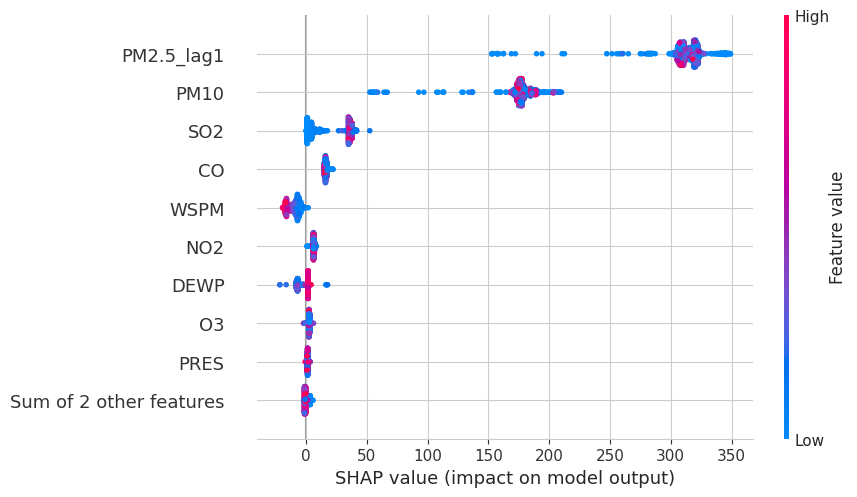

In [62]:
# If SHAP is not installed, run:
# !pip install shap -q

import shap

explainer = shap.Explainer(model)
shap_values = explainer(X_test[:1000])

shap.plots.beeswarm(shap_values)

# Streamlit App Preparation

After building the model, I prepare the files required for the Streamlit dashboard.  
The cleaned dataset and trained model must be saved in the same working directory as the app file.

## 63. Saving Final Dataset and Model for the App

This step ensures that both the cleaned dataset and trained model are available for the Streamlit dashboard.

In [63]:
df.to_csv("cleaned_selected_air_quality.csv", index=False)
print("Cleaned dataset saved.")

import joblib

joblib.dump(best_model, "best_pm25_model.pkl")
print("Model saved.")

Cleaned dataset saved.
Model saved.


## 64. Checking Required Files

Before running the app, I confirm that the cleaned dataset and model file exist in the working directory.

In [64]:
import os

print(os.path.exists("cleaned_selected_air_quality.csv"))
print(os.path.exists("best_pm25_model.pkl"))

True
True


## 65. Installing Streamlit and Required Packages

Streamlit is used to build the interactive dashboard.  
Pyngrok is used to expose the Streamlit app from Google Colab through a public URL.

In [65]:
!pip install streamlit pyngrok joblib plotly -q

## 66. Creating the Streamlit App File

This cell writes the full Streamlit dashboard code into a file called `app.py`.  
The app includes dataset overview, visual analytics, station comparison, and PM2.5 prediction.

In [66]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import plotly.express as px
import plotly.graph_objects as go

st.set_page_config(
    page_title="Beijing Air Pollution Intelligence Dashboard",
    page_icon="🌫️",
    layout="wide",
    initial_sidebar_state="expanded"
)

# =========================
# CSS DESIGN
# =========================
st.markdown("""
<style>
[data-testid="stSidebar"] {
    background: linear-gradient(180deg, #020617, #1e293b);
}
[data-testid="stSidebar"] * {
    color: white !important;
}
.block-container {
    padding-top: 1.5rem;
}
.hero {
    background: linear-gradient(135deg, #0f172a, #1e40af);
    padding: 28px;
    border-radius: 22px;
    color: white;
    margin-bottom: 20px;
}
.hero h1 {
    font-size: 42px;
    font-weight: 800;
}
.hero p {
    font-size: 18px;
    color: #dbeafe;
}
.card {
    background: white;
    padding: 20px;
    border-radius: 18px;
    box-shadow: 0 6px 20px rgba(15,23,42,0.08);
    border: 1px solid #e2e8f0;
}
.metric-title {
    color: #64748b;
    font-size: 14px;
    font-weight: 600;
}
.metric-value {
    color: #0f172a;
    font-size: 28px;
    font-weight: 800;
}
.insight-box {
    background: #eff6ff;
    border-left: 6px solid #2563eb;
    padding: 16px;
    border-radius: 12px;
    color: #1e3a8a;
    margin-top: 10px;
}
.warning-box {
    background: #fff7ed;
    border-left: 6px solid #f97316;
    padding: 16px;
    border-radius: 12px;
    color: #9a3412;
    margin-top: 10px;
}
.danger-box {
    background: #fef2f2;
    border-left: 6px solid #dc2626;
    padding: 16px;
    border-radius: 12px;
    color: #991b1b;
    margin-top: 10px;
}
.footer {
    text-align: center;
    color: #64748b;
    margin-top: 30px;
}
</style>
""", unsafe_allow_html=True)

# =========================
# LOAD DATA + MODEL
# =========================
@st.cache_data
def load_data():
    df = pd.read_csv("cleaned_selected_air_quality.csv")
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")

    if "season" not in df.columns:
        def get_season(month):
            if month in [3, 4, 5]:
                return "Spring"
            elif month in [6, 7, 8]:
                return "Summer"
            elif month in [9, 10, 11]:
                return "Autumn"
            else:
                return "Winter"
        df["season"] = df["month"].apply(get_season)

    if "area_type" not in df.columns:
        df["area_type"] = df["station"].map({
            "Dongsi": "Urban",
            "Guanyuan": "Urban",
            "Changping": "Suburban",
            "Huairou": "Suburban"
        })

    return df

@st.cache_resource
def load_model():
    return joblib.load("best_pm25_model.pkl")

df = load_data()
model = load_model()

# =========================
# CHINA AQI CATEGORY
# Source: China HJ 633-2012 AQI technical regulation, based on national AQI PM2.5 24-hour breakpoints.
# Reference source comment: Ministry of Ecology and Environment of China, Ambient Air Quality Standards GB 3095-2012.
# =========================
def china_pm25_category(value):
    if pd.isna(value):
        return "Unknown", "#94a3b8"
    elif value <= 35:
        return "Excellent", "#22c55e"
    elif value <= 75:
        return "Good", "#84cc16"
    elif value <= 115:
        return "Lightly Polluted", "#facc15"
    elif value <= 150:
        return "Moderately Polluted", "#f97316"
    elif value <= 250:
        return "Heavily Polluted", "#ef4444"
    else:
        return "Severely Polluted", "#7f1d1d"

def metric_card(title, value):
    st.markdown(
        f"""
        <div class="card">
            <div class="metric-title">{title}</div>
            <div class="metric-value">{value}</div>
        </div>
        """,
        unsafe_allow_html=True
    )

# =========================
# SIDEBAR
# =========================
st.sidebar.title("🌫️ Beijing Air Dashboard")
st.sidebar.write("Interactive air pollution analysis and PM2.5 prediction platform.")

page = st.sidebar.radio(
    "Navigation",
    [
        "🏠 Home",
        "📊 Dataset Overview",
        "📈 EDA",
        "🏙️ Station Intelligence",
        "🔮 Prediction Lab"
    ]
)

st.sidebar.markdown("---")

stations = sorted(df["station"].dropna().unique())
selected_stations = st.sidebar.multiselect(
    "Select Station",
    stations,
    default=stations
)

date_min = df["datetime"].min().date()
date_max = df["datetime"].max().date()

date_range = st.sidebar.date_input(
    "Select Date Range",
    value=(date_min, date_max),
    min_value=date_min,
    max_value=date_max
)

if len(date_range) == 2:
    start_date, end_date = date_range
else:
    start_date, end_date = date_min, date_max

filtered_df = df[
    (df["station"].isin(selected_stations)) &
    (df["datetime"].dt.date >= start_date) &
    (df["datetime"].dt.date <= end_date)
].copy()

# Avoid blank app if no data selected
if filtered_df.empty:
    st.warning("No data available for the selected filters. Please select at least one station and a valid date range.")
    st.stop()

# =========================
# HOME
# =========================
if page == "🏠 Home":
    st.markdown("""
    <div class="hero">
        <h1>Beijing Air Pollution Intelligence Dashboard</h1>
        <p>A professional dashboard for exploring PM2.5 pollution, station behaviour, weather influence, and machine learning prediction.</p>
    </div>
    """, unsafe_allow_html=True)

    avg_pm25 = filtered_df["PM2.5"].mean()
    max_pm25 = filtered_df["PM2.5"].max()
    category, color = china_pm25_category(avg_pm25)

    c1, c2, c3, c4 = st.columns(4)
    with c1:
        metric_card("Total Records", f"{len(filtered_df):,}")
    with c2:
        metric_card("Stations Analysed", filtered_df["station"].nunique())
    with c3:
        metric_card("Average PM2.5", f"{avg_pm25:.2f}")
    with c4:
        metric_card("China AQI Category", category)

    st.markdown(
        f"""
        <div class="insight-box">
        <b>Dashboard Insight:</b> The selected data has an average PM2.5 value of
        <b>{avg_pm25:.2f}</b>, which falls under the Chinese AQI category:
        <b style="color:{color};">{category}</b>.
        </div>
        """,
        unsafe_allow_html=True
    )

    col1, col2 = st.columns([2, 1])

    with col1:
        monthly = filtered_df.groupby(pd.Grouper(key="datetime", freq="M"))["PM2.5"].mean().reset_index()
        fig = px.line(
            monthly,
            x="datetime",
            y="PM2.5",
            markers=True,
            title="Monthly PM2.5 Trend"
        )
        fig.add_hline(y=75, line_dash="dash", line_color="orange", annotation_text="Good Limit")
        fig.add_hline(y=150, line_dash="dash", line_color="red", annotation_text="Moderate Pollution Limit")
        fig.update_layout(template="plotly_white", height=450)
        st.plotly_chart(fig, use_container_width=True)

    with col2:
        pollutant_avg = filtered_df[["PM2.5", "PM10", "SO2", "NO2", "CO", "O3"]].mean().sort_values(ascending=False)
        fig2 = px.bar(
            x=pollutant_avg.index,
            y=pollutant_avg.values,
            title="Average Pollutant Profile",
            labels={"x": "Pollutant", "y": "Average Value"}
        )
        fig2.update_layout(template="plotly_white", height=450)
        st.plotly_chart(fig2, use_container_width=True)

# =========================
# DATASET OVERVIEW
# =========================
elif page == "📊 Dataset Overview":
    st.markdown("""
    <div class="hero">
        <h1>Dataset Overview</h1>
        <p>This section explains the structure, completeness, and statistical behaviour of the selected Beijing air pollution dataset.</p>
    </div>
    """, unsafe_allow_html=True)

    c1, c2, c3 = st.columns(3)
    with c1:
        metric_card("Rows", f"{filtered_df.shape[0]:,}")
    with c2:
        metric_card("Columns", filtered_df.shape[1])
    with c3:
        metric_card("Missing Values", f"{filtered_df.isnull().sum().sum():,}")

    st.subheader("Sample Dataset")
    st.dataframe(filtered_df.head(30), use_container_width=True)

    st.subheader("Missing Value Summary")
    missing = pd.DataFrame({
        "Column": filtered_df.columns,
        "Missing Values": filtered_df.isnull().sum().values,
        "Missing Percentage": (filtered_df.isnull().sum().values / len(filtered_df)) * 100
    }).sort_values("Missing Values", ascending=False)
    st.dataframe(missing, use_container_width=True)

    st.subheader("Statistical Summary")
    st.dataframe(filtered_df.describe().T, use_container_width=True)

    csv = filtered_df.to_csv(index=False).encode("utf-8")
    st.download_button(
        "⬇ Download Filtered Dataset",
        data=csv,
        file_name="filtered_beijing_air_quality.csv",
        mime="text/csv"
    )

# =========================
# Storytelling EDA
# =========================
elif page == "📈 EDA":
    st.markdown("""
    <div class="hero">
        <h1>EDA</h1>
        <p>This section does not only show charts. It explains where pollution is highest, when it becomes dangerous, and why it may happen.</p>
    </div>
    """, unsafe_allow_html=True)

    tab1, tab2, tab3, tab4, tab5 = st.tabs([
        "1️⃣ Time Based",
        "2️⃣ Station Based",
        "3️⃣ Weather Based",
        "4️⃣ Pollution Events",
        "5️⃣ Advanced Research View"
    ])

    with tab1:
        st.subheader("How does PM2.5 change over time?")
        monthly = filtered_df.groupby(pd.Grouper(key="datetime", freq="M"))["PM2.5"].mean().reset_index()
        fig = px.line(monthly, x="datetime", y="PM2.5", markers=True, title="Monthly Average PM2.5 Over Time")
        fig.add_hline(y=75, line_dash="dash", line_color="orange")
        fig.add_hline(y=150, line_dash="dash", line_color="red")
        fig.update_layout(template="plotly_white", height=500)
        st.plotly_chart(fig, use_container_width=True)

        st.markdown("""
        <div class="insight-box">
        <b>Insight:</b> Monthly PM2.5 patterns show repeated seasonal peaks. This suggests that air pollution is not random; it is strongly connected with time, season, and environmental conditions.
        </div>
        """, unsafe_allow_html=True)

        hourly = filtered_df.groupby("hour")["PM2.5"].mean().reset_index()
        fig2 = px.line(hourly, x="hour", y="PM2.5", markers=True, title="Average PM2.5 by Hour of Day")
        fig2.update_layout(template="plotly_white", height=420)
        st.plotly_chart(fig2, use_container_width=True)

    with tab2:
        st.subheader("Which station is most polluted?")
        station_avg = filtered_df.groupby(["station", "area_type"])["PM2.5"].mean().reset_index().sort_values("PM2.5", ascending=False)

        fig = px.bar(
            station_avg,
            x="station",
            y="PM2.5",
            color="area_type",
            title="Average PM2.5 by Station and Area Type",
            text_auto=".2f"
        )
        fig.update_layout(template="plotly_white", height=480)
        st.plotly_chart(fig, use_container_width=True)

        st.markdown("""
        <div class="insight-box">
        <b>Insight:</b> Station-level comparison helps identify pollution hotspots. Urban stations often show higher pollution pressure due to traffic density and human activity.
        </div>
        """, unsafe_allow_html=True)

        fig2 = px.box(
            filtered_df,
            x="station",
            y="PM2.5",
            color="area_type",
            title="PM2.5 Spread and Extreme Values by Station"
        )
        fig2.update_layout(template="plotly_white", height=500)
        st.plotly_chart(fig2, use_container_width=True)

    with tab3:
        st.subheader("How do weather conditions affect pollution?")

        filtered_df["wind_condition"] = np.where(filtered_df["WSPM"] < 2, "Low Wind", "Higher Wind")
        wind_station = filtered_df.groupby(["station", "wind_condition"])["PM2.5"].mean().reset_index()

        fig = px.bar(
            wind_station,
            x="station",
            y="PM2.5",
            color="wind_condition",
            barmode="group",
            title="Impact of Wind Conditions on PM2.5 by Station",
            text_auto=".2f"
        )
        fig.update_layout(template="plotly_white", height=480)
        st.plotly_chart(fig, use_container_width=True)

        st.markdown("""
        <div class="warning-box">
        <b>Insight:</b> PM2.5 is usually higher during low-wind conditions. This suggests that stagnant air prevents pollutants from dispersing.
        </div>
        """, unsafe_allow_html=True)

        sample = filtered_df[["TEMP", "WSPM", "PM2.5", "station"]].dropna()
        if len(sample) > 5000:
            sample = sample.sample(5000, random_state=42)

        fig2 = px.scatter_3d(
            sample,
            x="TEMP",
            y="WSPM",
            z="PM2.5",
            color="station",
            title="3D Weather-Pollution Relationship"
        )
        fig2.update_layout(height=650)
        st.plotly_chart(fig2, use_container_width=True)

    with tab4:
        st.subheader("When does pollution become dangerous?")

        filtered_df["date"] = filtered_df["datetime"].dt.date
        daily = filtered_df.groupby("date").agg(
            avg_pm25=("PM2.5", "mean"),
            max_pm25=("PM2.5", "max")
        ).reset_index()

        fig = go.Figure()
        fig.add_trace(go.Scatter(x=daily["date"], y=daily["avg_pm25"], mode="lines", name="Daily Average PM2.5"))
        fig.add_trace(go.Scatter(
            x=daily[daily["avg_pm25"] > 150]["date"],
            y=daily[daily["avg_pm25"] > 150]["avg_pm25"],
            mode="markers",
            name="Extreme Days",
            marker=dict(color="red", size=8)
        ))
        fig.add_hline(y=150, line_dash="dash", line_color="red", annotation_text="Moderately Polluted Threshold")
        fig.update_layout(title="Extreme Pollution Episodes Over Time", template="plotly_white", height=500)
        st.plotly_chart(fig, use_container_width=True)

        top_days = daily.sort_values("avg_pm25", ascending=False).head(10)
        fig2 = px.bar(
            top_days,
            x="date",
            y="avg_pm25",
            title="Top 10 Most Polluted Days",
            text_auto=".2f"
        )
        fig2.update_layout(template="plotly_white", height=420)
        st.plotly_chart(fig2, use_container_width=True)

        st.markdown("""
        <div class="danger-box">
        <b>Insight:</b> Extreme pollution appears in clusters, not as single random events. This shows that dangerous pollution may be caused by sustained environmental and emission conditions.
        </div>
        """, unsafe_allow_html=True)

    with tab5:
        st.subheader("Research-style station similarity and atmospheric risk")

        station_monthly = filtered_df.pivot_table(
            values="PM2.5",
            index=filtered_df["datetime"].dt.to_period("M").astype(str),
            columns="station",
            aggfunc="mean"
        )

        station_corr = station_monthly.corr()

        fig = go.Figure(data=go.Heatmap(
            z=station_corr.values,
            x=station_corr.columns,
            y=station_corr.index,
            colorscale="Blues",
            text=np.round(station_corr.values, 2),
            texttemplate="%{text}",
            zmin=0,
            zmax=1
        ))
        fig.update_layout(title="Station Similarity Based on Monthly PM2.5 Behaviour", template="plotly_white", height=550)
        st.plotly_chart(fig, use_container_width=True)

        filtered_df["condition_type"] = np.select(
            [
                (filtered_df["TEMP"] < 0) & (filtered_df["WSPM"] < 2),
                (filtered_df["TEMP"] < 0) & (filtered_df["WSPM"] >= 2),
                (filtered_df["TEMP"] >= 0) & (filtered_df["WSPM"] < 2),
                (filtered_df["TEMP"] >= 0) & (filtered_df["WSPM"] >= 2)
            ],
            [
                "Cold + Low Wind",
                "Cold + Higher Wind",
                "Warm + Low Wind",
                "Warm + Higher Wind"
            ],
            default="Other"
        )

        condition_station = filtered_df.groupby(["condition_type", "station"])["PM2.5"].mean().reset_index()
        order = ["Cold + Low Wind", "Cold + Higher Wind", "Warm + Low Wind", "Warm + Higher Wind"]

        fig2 = px.bar(
            condition_station,
            x="condition_type",
            y="PM2.5",
            color="station",
            barmode="group",
            category_orders={"condition_type": order},
            title="PM2.5 Risk Under Combined Temperature and Wind Conditions",
            text_auto=".2f"
        )
        fig2.update_layout(template="plotly_white", height=500, xaxis_tickangle=-20)
        st.plotly_chart(fig2, use_container_width=True)

# =========================
# STATION INTELLIGENCE
# =========================
elif page == "🏙️ Station Intelligence":
    st.markdown("""
    <div class="hero">
        <h1>Station Intelligence</h1>
        <p>This section compares stations like an environmental monitoring report.</p>
    </div>
    """, unsafe_allow_html=True)

    metric = st.selectbox("Choose variable to compare", ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3", "TEMP", "WSPM"])

    station_summary = filtered_df.groupby(["station", "area_type"])[metric].agg(["mean", "max", "std"]).reset_index()
    station_summary.columns = ["Station", "Area Type", "Average", "Maximum", "Variability"]

    st.dataframe(station_summary.round(2), use_container_width=True)

    fig = px.scatter(
        station_summary,
        x="Average",
        y="Variability",
        size="Maximum",
        color="Area Type",
        hover_name="Station",
        title=f"Station Risk Map for {metric}",
        labels={"Average": "Average Level", "Variability": "Pollution Instability"}
    )
    fig.update_layout(template="plotly_white", height=520)
    st.plotly_chart(fig, use_container_width=True)

    st.markdown("""
    <div class="insight-box">
    <b>Insight:</b> A station with both high average pollution and high variability is more risky because it experiences both regular pollution and sudden extreme events.
    </div>
    """, unsafe_allow_html=True)

# =========================
# PREDICTION LAB
# =========================
elif page == "🔮 Prediction Lab":
    st.markdown("""
    <div class="hero">
        <h1>PM2.5 Prediction Lab</h1>
        <p>Enter pollutant and weather values to predict PM2.5 concentration using the tuned Random Forest model.</p>
    </div>
    """, unsafe_allow_html=True)

    col1, col2 = st.columns(2)

    with col1:
        PM10 = st.slider("PM10", 0.0, 500.0, 80.0)
        SO2 = st.slider("SO2", 0.0, 100.0, 10.0)
        NO2 = st.slider("NO2", 0.0, 200.0, 40.0)
        CO = st.slider("CO", 0.0, 5000.0, 800.0)
        O3 = st.slider("O3", 0.0, 300.0, 50.0)
        PM25_lag1 = st.slider("Previous Hour PM2.5", 0.0, 500.0, 75.0)

    with col2:
        TEMP = st.slider("Temperature", -30.0, 45.0, 20.0)
        PRES = st.slider("Pressure", 980.0, 1050.0, 1010.0)
        DEWP = st.slider("Dew Point", -40.0, 30.0, 10.0)
        RAIN = st.slider("Rain", 0.0, 50.0, 0.0)
        WSPM = st.slider("Wind Speed", 0.0, 15.0, 2.5)

    input_df = pd.DataFrame([{
        "PM10": PM10,
        "SO2": SO2,
        "NO2": NO2,
        "CO": CO,
        "O3": O3,
        "TEMP": TEMP,
        "PRES": PRES,
        "DEWP": DEWP,
        "RAIN": RAIN,
        "WSPM": WSPM,
        "PM2.5_lag1": PM25_lag1
    }])

    if st.button("🔮 Predict PM2.5"):
        prediction = model.predict(input_df)[0]
        category, color = china_pm25_category(prediction)

        st.markdown(
            f"""
            <div class="card">
                <h2>Predicted PM2.5: <span style="color:{color};">{prediction:.2f}</span></h2>
                <h3>China AQI Category: <span style="color:{color};">{category}</span></h3>
            </div>
            """,
            unsafe_allow_html=True
        )

        gauge = go.Figure(go.Indicator(
            mode="gauge+number",
            value=prediction,
            title={"text": "Predicted PM2.5"},
            gauge={
                "axis": {"range": [0, max(500, prediction + 50)]},
                "bar": {"color": color},
                "steps": [
                    {"range": [0, 35], "color": "#bbf7d0"},
                    {"range": [35, 75], "color": "#d9f99d"},
                    {"range": [75, 115], "color": "#fef08a"},
                    {"range": [115, 150], "color": "#fdba74"},
                    {"range": [150, 250], "color": "#fca5a5"},
                    {"range": [250, 500], "color": "#7f1d1d"}
                ]
            }
        ))
        gauge.update_layout(template="plotly_white", height=380)
        st.plotly_chart(gauge, use_container_width=True)

        if prediction > 150:
            st.markdown("""
            <div class="danger-box">
            <b>Risk Message:</b> The predicted PM2.5 level is high. Sensitive groups should reduce outdoor activities.
            </div>
            """, unsafe_allow_html=True)
        elif prediction > 75:
            st.markdown("""
            <div class="warning-box">
            <b>Risk Message:</b> Air quality is not ideal. Pollution control and public awareness are important.
            </div>
            """, unsafe_allow_html=True)
        else:
            st.markdown("""
            <div class="insight-box">
            <b>Risk Message:</b> The predicted air quality is relatively acceptable under the selected conditions.
            </div>
            """, unsafe_allow_html=True)

st.markdown("---")
st.markdown(
    "<div class='footer'>Developed for CMP7005 Programming for Data Analysis | Beijing Air Pollution Dashboard</div>",
    unsafe_allow_html=True
)

Overwriting app.py


## 67. Checking Project Files

This command lists the files in the current directory.  
It is used to confirm that `app.py`, the cleaned dataset, and the trained model file are present before running the app.

In [67]:
!ls

 all_cities_combined.csv
 app.py
 best_pm25_model.pkl
 cleaned_selected_air_quality.csv
 Programming_for_Data_Analysis_Project.ipynb
 PRSA_Data_Changping_20130301-20170228.csv
'PRSA_Data_Dongsi_20130301-20170228 (1).csv'
 PRSA_Data_Dongsi_20130301-20170228.csv
 PRSA_Data_Guanyuan_20130301-20170228.csv
 PRSA_Data_Huairou_20130301-20170228.csv
 selected_stations_combined.csv


## 68. Running the Streamlit App

This command starts the Streamlit app in the background inside Colab.

In [68]:
!streamlit run app.py &>/content/logs.txt &

## 69. Creating a Public URL with Ngrok

Because Streamlit runs inside Colab, Ngrok is used to create a public link.  
Open the printed URL to access the dashboard in a browser.

If Ngrok asks for an authentication token, use:



In [69]:
from pyngrok import ngrok
ngrok.set_auth_token("3CGV2R1oj9B053EWqUY15wLAlka_7XUkonBkU7yBFrp1WborR")
public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://ferret-game-ember.ngrok-free.dev" -> "http://localhost:8501"


In [70]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://ferret-game-ember.ngrok-free.dev" -> "http://localhost:8501"
